## **1. Introduction: Image Enhancement in the Frequency Domain**

### Concept Overview

Image enhancement is a fundamental area of digital image processing aimed at improving the visual quality of images or making them more suitable for analysis and interpretation. Also, another objective of image enhancement is to process an image so that the result is more suitable than the original for a specific application. While spatial domain enhancement deals with direct pixel manipulation, this project focuses on the Frequency Domain. This is mainly because many forms of image degradation such as noise, blur, and poor contrast can be effectively analyzed in the frequency domain rather than in the spatial domain.

As discussed in Gonzalez & Woods (Chapter 4), frequency domain processing is based on the Fourier Transform. In this context, "frequency" refers to the rate of change of pixel intensities. The Fourier Transform converts an image from the spatial domain (pixel intensities) into the frequency domain. In the frequency representation:
* Low frequencies correspond to slowly varying intensities, representing the overall appearance and smooth areas of an image.
* High frequencies correspond to fast-varying intensities, representing edges, fine details, and noise.
  
By transforming an image into its frequency components, we can apply filters that selectively suppress or emphasize specific frequency ranges—such as smoothing an image by removing high frequencies or sharpening it by removing low frequencies.

This project investigates image enhancement using the 2D Fourier Transform and frequency filtering.



## 2. Methodology: Mathematical Framework

In the frequency domain, we treat an image as a distribution of intensities that can be decomposed into various spatial frequencies. The mathematical framework for this project relies on the **Discrete Fourier Transform (DFT)** to transition from the spatial domain (pixels) to the frequency domain (spectrum). By manipulating the frequency components through multiplication with a filter transfer function and then applying the Inverse DFT, we can achieve specific enhancement goals such as noise reduction or edge sharpening.

### 2.1 The 2D Discrete Fourier Transform (DFT)
As discussed in Gonzalez & Woods (Chapter 4), an image $f(x, y)$ of size $M \times N$ is converted into the frequency domain using the 2D DFT. This transform represents the image as a weighted sum of complex sinusoids:
$$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$
The inverse process (IDFT) allows us to return to the spatial domain after filtering:$$f(x, y) = \frac{1}{MN} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F(u, v) e^{j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$
Where:<br>
𝒇(𝒙, 𝒚)= spatial domain image <br>
𝑭(𝒖, 𝒗)= frequency domain representation<br>
𝑴, 𝑵= image dimensions<br>
𝒋= imaginary unit
<br>
<br>

### 2.2 The Fourier Spectrum and Centering
The result $F(u, v)$ consists of complex numbers. To analyze and visualize the frequencies, we calculate the Magnitude Spectrum:$$|F(u, v)| = \sqrt{R(u, v)^2 + I(u, v)^2}$$
In a raw DFT, the low-frequency components (which contain the bulk of the image energy) are located at the corners of the transform. To move these to the center for easier filtering, we apply a shift. Mathematically, this is equivalent to multiplying the original image by $(-1)^{x+y}$ before the transform.
<br>
<br>

### 2.3 The Distance Function $D(u, v)$
Frequency filtering depends on the distance of a point $(u, v)$ from the center of the frequency rectangle. If the transform is centered at $(u_0, v_0) = (M/2, N/2)$, the distance $D(u, v)$ is defined by the Euclidean distance:$$D(u, v) = \sqrt{(u - M/2)^2 + (v - N/2)^2}$$

### 2.4 Frequency Domain Filtering Model
The enhancement process is mathematically modeled as the point-wise multiplication of the centered Fourier Transform by a filter transfer function $H(u, v)$:$$G(u, v) = H(u, v)F(u, v)$$
Where:<br>
- Lowpass Filtering: $H(u, v)$ attenuates high values of $D(u, v)$, resulting in image blurring or noise reduction.
- Highpass Filtering: $H(u, v)$ attenuates low values of $D(u, v)$, resulting in edge enhancement and sharpening.



## 3. Project Implementation
This section details the practical implementation of the Fourier Transform and frequency filtering using Python. To achieve efficient numerical computation and visualization, we leverage three core libraries:
- NumPy: Essential for performing the Fast Fourier Transform (A highly optimized algorithm used in computing the DFT) and managing images as complex-valued numerical arrays.
- OpenCV: Used for robust image input/output operations, specifically for reading the original image and preparing it for processing.
- Matplotlib: Utilized to visualize the frequency spectrum and provide side-by-side comparisons of the original and enhanced images.<br>

The implementation follows a modular approach. We begin by transforming the spatial image into its frequency representation, followed by the construction and application of the Ideal Lowpass and Ideal Highpass filters.

**Step 1: Importing Dependencies** <br>
The first step is to load the necessary Python libraries for image handling, numerical computation, and visualization.

In [1]:
import cv2  # For image I/O and spatial processing
import numpy as np  # For FFT and matrix operations
import matplotlib.pyplot as plt  # For displaying results
import os  # To handle file paths within the IMG_data structure

**Step 2: Loading and Pre-processing Images** <br>
This step involves reading the images from the IMG_data/original/ folder. For frequency domain processing, images are converted to grayscale and then to a floating-point format to prevent data loss during complex mathematical operations.

In [2]:
# Define the path to your original images folder
image_folder = '../IMG_data/original/'

# List of images to process (add all your filenames here)
image_files = [
    'img1.jpg',
    'img2.jpg',
    'img3.jpg',
    'img4.jpg',
    'img5.jpg'
]

# Function to load an image in grayscale
def load_image(filename):
    path = os.path.join(image_folder, filename)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not load {filename}")
    return img

# Load the first image as a starting point
original_img = load_image(image_files[0])

# Verify it worked
if original_img is not None:
    print(f"Successfully loaded: {image_files[0]}")
    print(f"Image Resolution: {original_img.shape}")

Successfully loaded: img1.jpg
Image Resolution: (977, 736)


**Step 3: Computing the Centered Fourier Transform** <br>
To analyze the image in the frequency domain, we compute the 2D DFT using the Fast Fourier Transform (FFT) algorithm. We then shift the zero-frequency component to the center of the spectrum for easier filtering.

In [3]:
def compute_fft(image):
    # Compute the 2D Fast Fourier Transform
    dft = np.fft.fft2(image)
    
    # Shift the zero-frequency component to the center of the spectrum
    dft_shifted = np.fft.fftshift(dft)
    
    # Calculate Magnitude Spectrum for visualization (using log scale)
    magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)
    
    return dft_shifted, magnitude_spectrum

# Execute the transform
dft_centered, spectrum = compute_fft(original_img)

**Step 4: Visualizing the Original Image and Its Spectrum** <br>
Before applying filters, it is important to visualize the original content and its frequency distribution to verify the transform.

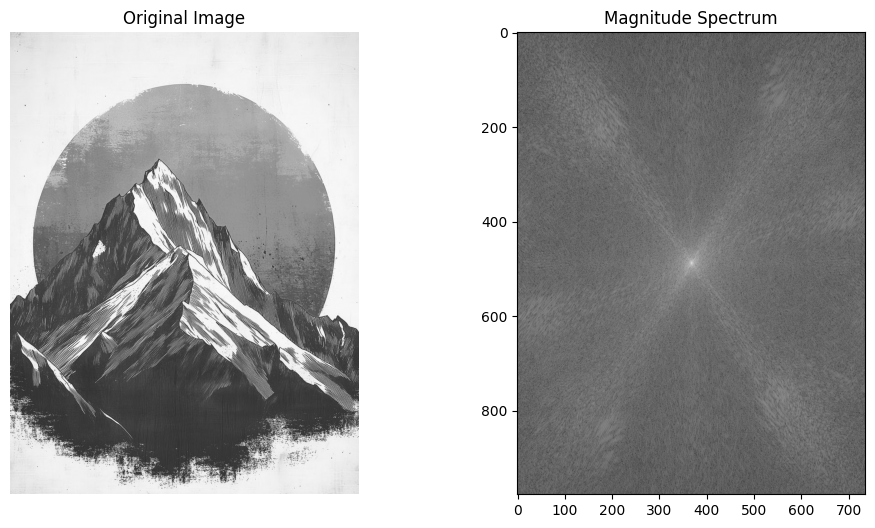

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(121), plt.imshow(original_img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(spectrum, cmap='gray')
plt.title('Magnitude Spectrum'), plt.axis('on')

plt.show()

**Step 5: Defining the Distance Function** <br>
Before creating filters, we must calculate the distance of each pixel in the frequency domain from the origin (center). This distance determines which frequencies are kept and which are filtered out.


In [5]:
def get_distance_array(shape):
    """Calculates the Euclidean distance from the center of the frequency rectangle."""
    M, N = shape
    u = np.arange(M)
    v = np.arange(N)
    
    # Shift indices so that the center is at (M/2, N/2)
    u, v = np.meshgrid(u - M//2, v - N//2, indexing='ij')
    
    # Compute Euclidean distance D(u, v)
    return np.sqrt(u**2 + v**2)

**Step 6: Creating the Filter Functions** <br>
We will now implement the Ideal Lowpass Filter (ILPF) and the Ideal Highpass Filter (IHPF) using the mathematical definitions provided in the theory section.

In [6]:
def ideal_lowpass_filter(shape, D0):
    """Creates an Ideal Lowpass Filter mask."""
    D = get_distance_array(shape)
    # H(u, v) = 1 if D <= D0, else 0
    return (D <= D0).astype(float)

def ideal_highpass_filter(shape, D0):
    """Creates an Ideal Highpass Filter mask."""
    # H(u, v) = 1 - ILPF
    return 1 - ideal_lowpass_filter(shape, D0)

**Step 7: Applying the Filters and Reconstructing the Image** <br>
To enhance the image, we multiply the centered DFT by the filter mask and then apply the Inverse Fast Fourier Transform (IFFT) to return to the spatial domain.

In [7]:
def apply_filter(dft_shifted, filter_mask):
    # Step 1: Multiply DFT by the filter mask
    filtered_dft = dft_shifted * filter_mask
    
    # Step 2: Inverse shift to move DC component back to corners
    f_ishift = np.fft.ifftshift(filtered_dft)
    
    # Step 3: Inverse FFT to get the image back
    img_back = np.fft.ifft2(f_ishift)
    
    # Step 4: Return the absolute value (magnitude) of the result
    return np.abs(img_back)

**Step 9: Saving Processed Images**<br>
This implementation stage involves creating a function that helps in exporting the frequency-filtered results from the system memory to the local storage. This step is critical for verifying that the enhancement algorithms that is, the Ideal Lowpass Filter (ILPF) and the Ideal Highpass Filter (IHPF)—successfully produced the intended effects.

In [8]:
# Define the path to your processed images folder
processed_folder = '../IMG_data/processed/'

# Create the directory if it doesn't exist
if not os.path.exists(processed_folder):
    os.makedirs(processed_folder)

def save_processed_results(filename, lp_result, hp_result):
    # Strip the original extension to create a new name
    base_name = os.path.splitext(filename)[0]
    
    # Normalize results to 0-255 range and convert to uint8 for saving
    lp_save = cv2.normalize(lp_result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    hp_save = cv2.normalize(hp_result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Define save paths
    lp_path = os.path.join(processed_folder, f"{base_name}_lowpass.jpg")
    hp_path = os.path.join(processed_folder, f"{base_name}_highpass.jpg")
    
    # Save the images
    cv2.imwrite(lp_path, lp_save)
    cv2.imwrite(hp_path, hp_save)
    
    print(f"Saved: {base_name}_lowpass.jpg and {base_name}_highpass.jpg")

# You can now call this inside your processing loop


**Step 9: Results Visualization** <br>
In this final implementation step, we apply the filtering pipeline to all images in the dataset. We use a fixed cutoff frequency ($D_0$) to demonstrate how the Ideal Lowpass Filter removes high-frequency details (blurring) and how the Ideal Highpass Filter isolates edges (sharpening).

Saved: img1_lowpass.jpg and img1_highpass.jpg
Saved: img2_lowpass.jpg and img2_highpass.jpg
Saved: img3_lowpass.jpg and img3_highpass.jpg
Saved: img4_lowpass.jpg and img4_highpass.jpg
Saved: img5_lowpass.jpg and img5_highpass.jpg


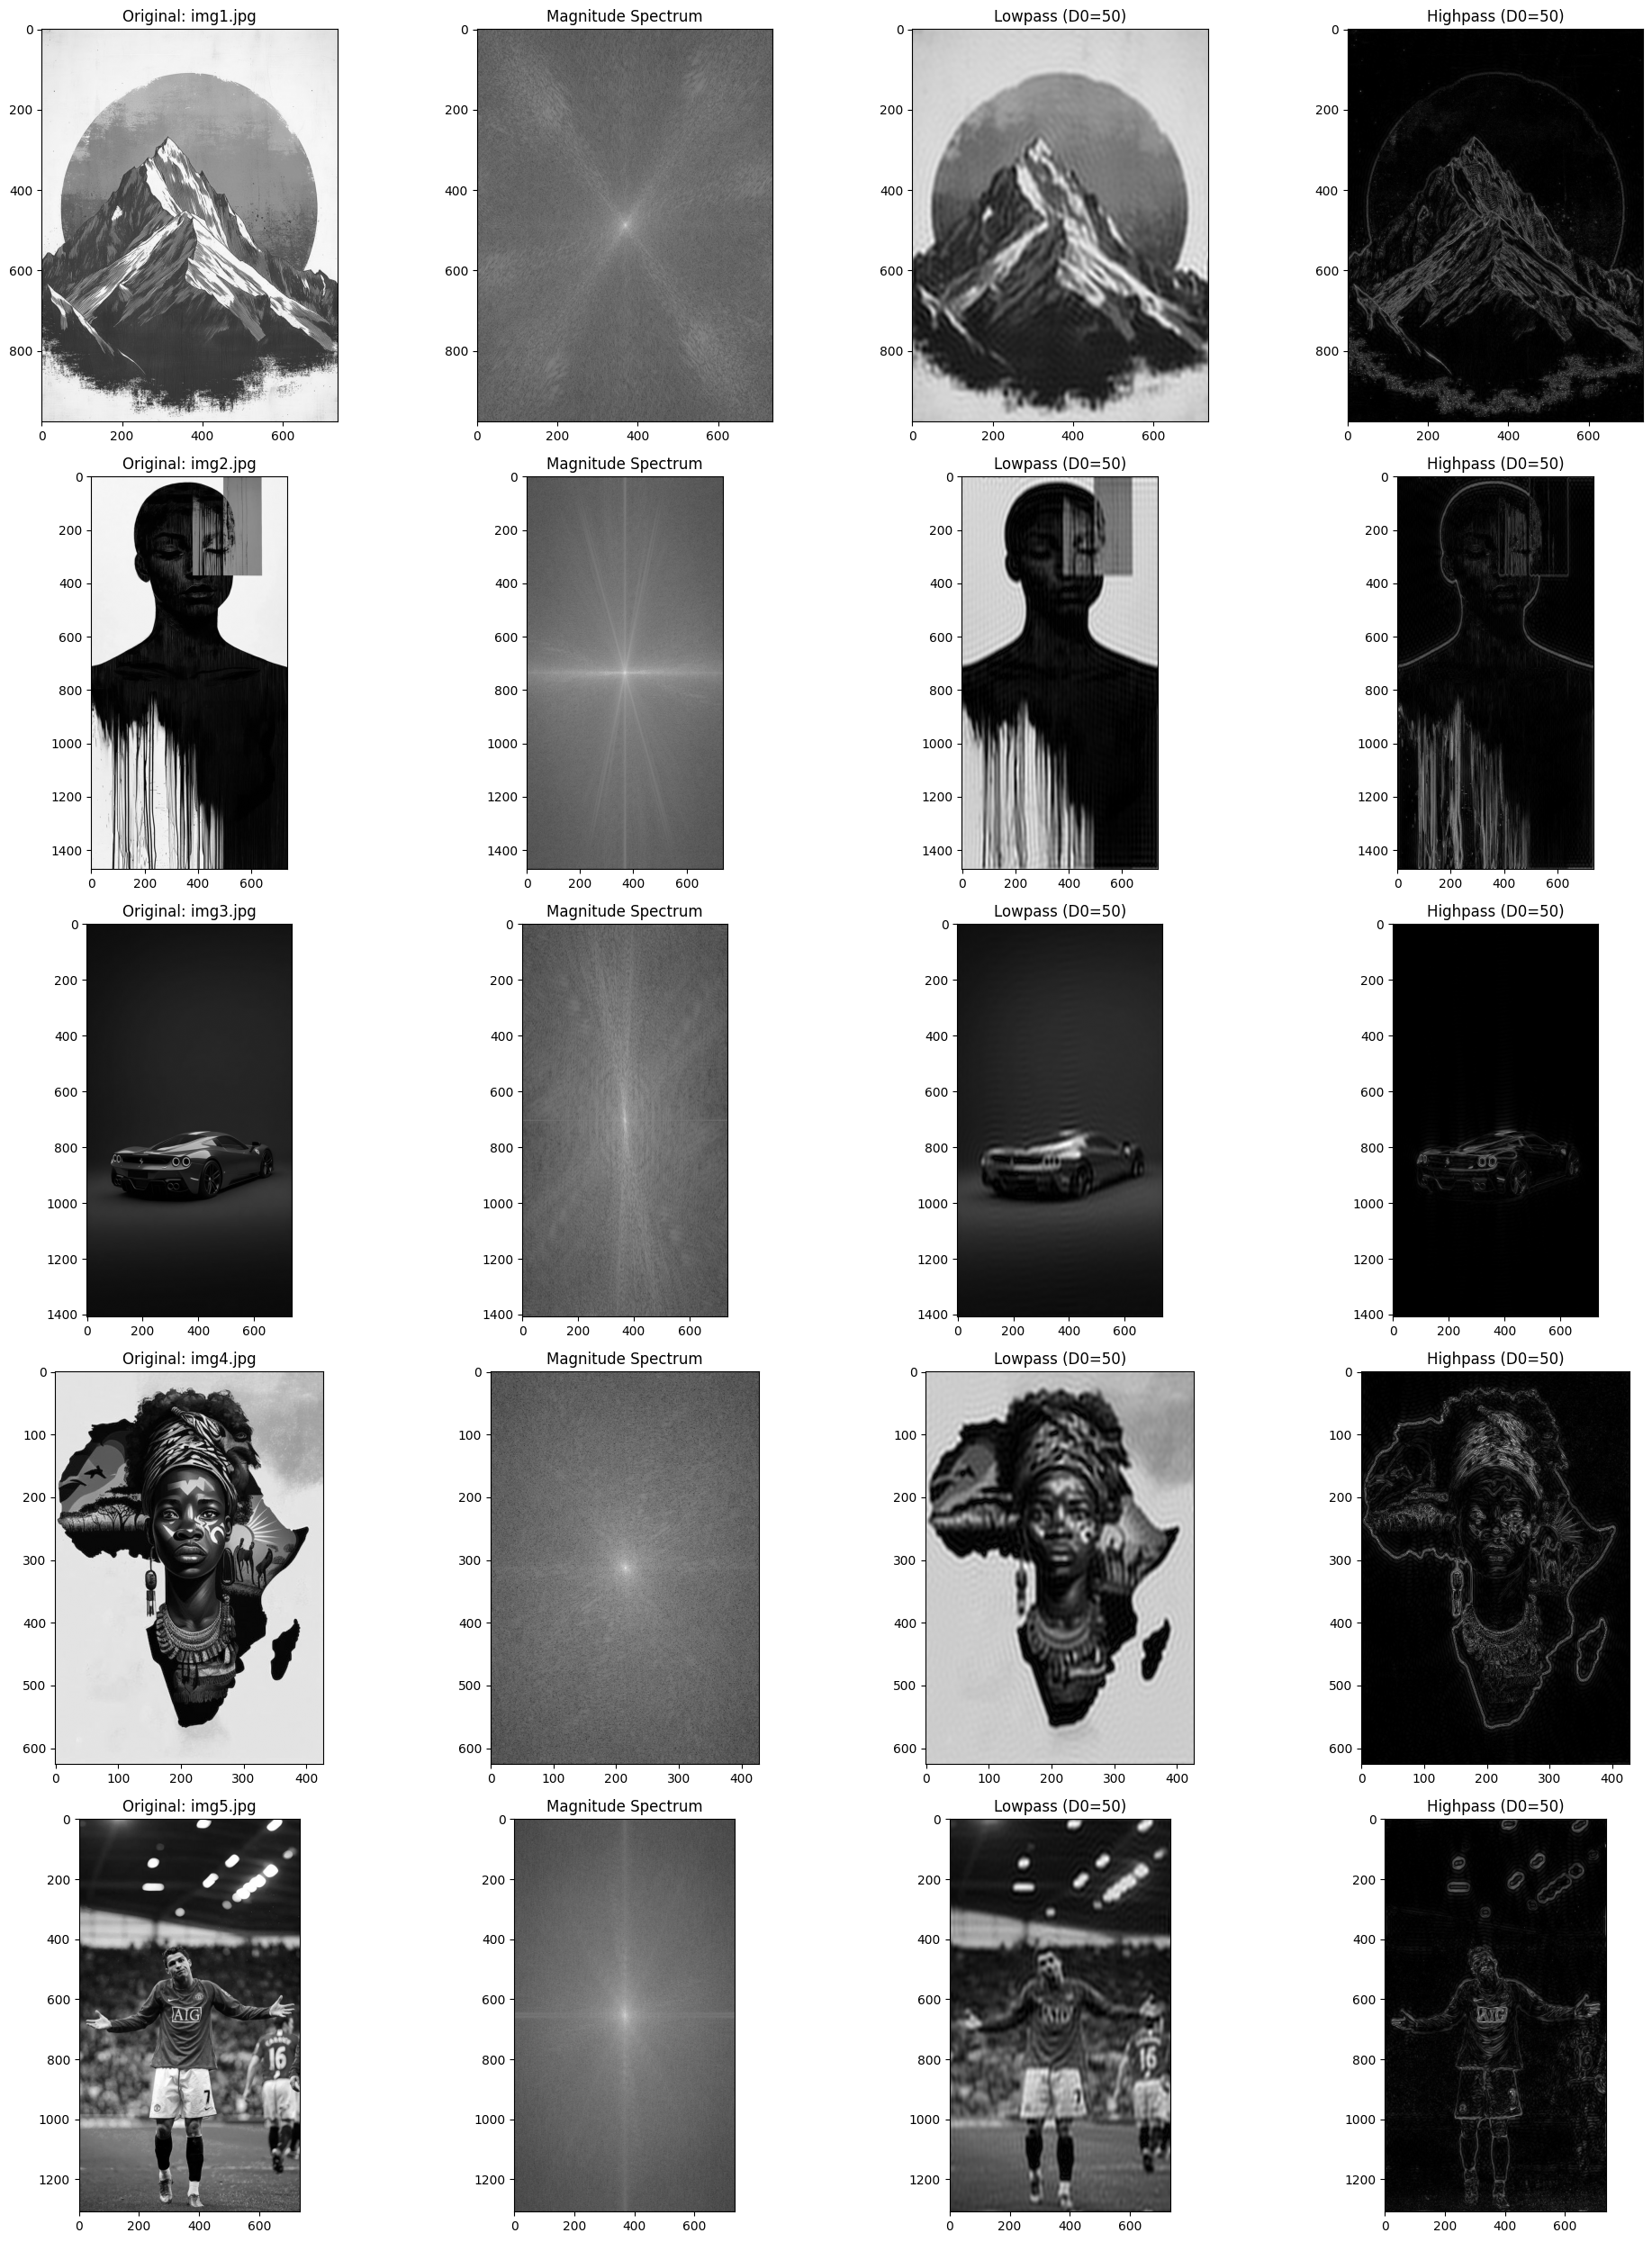

In [9]:
# Define parameters for the filters
cutoff_frequency = 50  # Adjust this value to change the level of blur/sharpening

def process_and_visualize(image_list):
    num_images = len(image_list)
    # Create a grid: Rows = Images, Columns = Original, Spectrum, Lowpass, Highpass
    fig, axes = plt.subplots(num_images, 4, figsize=(20, 5 * num_images))
    
    for i, filename in enumerate(image_list):
        # 1. Load and Transform
        img = load_image(filename)
        if img is None: continue
        
        dft_shift, mag_spectrum = compute_fft(img)
        
        # 2. Generate and Apply Filters
        rows, cols = img.shape
        lp_mask = ideal_lowpass_filter((rows, cols), cutoff_frequency)
        hp_mask = ideal_highpass_filter((rows, cols), cutoff_frequency)
        
        lowpass_results = apply_filter(dft_shift, lp_mask)
        highpass_results = apply_filter(dft_shift, hp_mask)

        # Calling the save function below to store all the results
        save_processed_results(filename, lowpass_results, highpass_results)
        
        # 3. Plotting
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'Original: {filename}')
        
        axes[i, 1].imshow(mag_spectrum, cmap='gray')
        axes[i, 1].set_title('Magnitude Spectrum')
        
        axes[i, 2].imshow(lowpass_results, cmap='gray')
        axes[i, 2].set_title(f'Lowpass (D0={cutoff_frequency})')
        
        axes[i, 3].imshow(highpass_results, cmap='gray')
        axes[i, 3].set_title(f'Highpass (D0={cutoff_frequency})')
        
        # for ax in axes[i]:
            # ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization for all 5 images
process_and_visualize(image_files)

## 4. Discussion<br>
### 4.1 Analysis of results
The experimental results demonstrate the fundamental principles of frequency domain processing and how an image can be decomposed into different frequency components to achieve specific enhancement goals as described in Gonzalez & Woods (Chapter 4).
- **Frequency Characteristics:** The Magnitude Spectrum for each image shows that the majority of visual energy is concentrated at the center (low frequencies). The bright spikes radiating outward correspond to sharp edges and fine textures in the original spatial image.
- **Smoothing Effect (ILPF):** The Ideal Lowpass Filter effectively attenuated high-frequency components. Visually, this resulted in a "blurred" image where sharp transitions were softened. We noted the presence of "Ringing Artifacts" that is faint concentric ripples around sharp edges or boundaries. This is a characteristic limitation of "Ideal" filters caused by the sharp mathematical cutoff in the frequency domain.
- **Sharpening Effect (IHPF):** The Ideal Highpass Filter suppressed the low-frequency background (DC component) and retained only the high-frequency transitions. The resulting images appear as "edge maps," where constant-intensity regions become black, and only structural boundaries remain visible creating this "Ghost-like" or "skecth" effect.

### 4.2 Strengths and Limitations
**Strengths:**<br> 
- Mathematical Precision: Ideal filters provide a "perfect" cutoff. There is no ambiguity; frequencies are either completely preserved or completely eliminated based on the $D_0$ threshold.
- Global Feature Control: Unlike spatial filters (like a 3x3 Mean filter) which only look at local neighbors, frequency domain filtering affects the entire image simultaneously. This makes it highly efficient for removing global periodic noise.
- Computational Efficiency: By leveraging the Fast Fourier Transform (FFT), processing large images is significantly faster than performing massive spatial convolutions, especially as the filter size increases. <br>
  
**Limitations:**<br> 
- The Ringing Effect (Gibbs Phenomenon): This is the most prominent drawback of "Ideal" filters. Because the transition between "pass" and "filter" is a sharp step function, it creates ripples in the spatial domain. This manifests as blurred "ghost" edges in the Lowpass results.
- High-Pass Noise Sensitivity: The Ideal Highpass Filter does not distinguish between an "edge" and "noise." Since both are high-frequency components, the filter often amplifies sensor grain or digital noise while trying to sharpen the image.
- Loss of Context: In Highpass filtering, the removal of the DC component (the average brightness) means the resulting image loses all sense of original lighting and color, which may not be desirable for simple aesthetic "sharpening."
  
### 4.3 Real-World Applications
The techniques implemented in this project are foundational to several modern technologies:<br>
1. **Medical Imaging (X-Rays/MRI):** Highpass filtering is used to sharpen bone structures and highlight small fractures or blood vessels that might be blurry in the raw scan.
2. **Satellite Imagery:** Lowpass filters are applied to smooth out "salt-and-pepper" noise caused by atmospheric interference, while Highpass filters help in detecting roads and building boundaries from space.
3. **Digital Photography:** Most "Portrait Mode" features use a form of lowpass filtering to blur the background (Bokeh effect), while "Sharpen" tools use highpass filtering to make features pop. 
4. **Data Compression:** Concepts from the Fourier Transform are used in JPEG compression, where high-frequency information (which the human eye notices less) is discarded to reduce file size.

## 6. Conclusion
The implementation of frequency domain enhancement successfully validates the mathematical theories proposed by Gonzalez & Woods. Through the application of the 2D Discrete Fourier Transform, we demonstrated that an image is not merely a collection of pixels, but a complex composite of varying frequencies.

The project reached the following conclusions:
- **Filter Duality:** The Ideal Lowpass Filter and Ideal Highpass Filter act as two sides of the same coin. While the ILPF achieves noise reduction through smoothing, the IHPF provides structural clarity through edge enhancement.
- **Frequency Localization:** The experiment confirmed that the "energy" of a natural image is primarily concentrated in the low-frequency range, whereas the "information" regarding boundaries and textures is stored in the high-frequency spectrum.
- **The "Ideal" Trade-off:** While Ideal filters are mathematically straightforward to implement, the observation of ringing artifacts (Gibbs Phenomenon) highlights the practical limitations of "hard" frequency cutoffs.<br>
  
Ultimately, this project illustrates how frequency domain manipulation offers a powerful alternative to spatial domain processing, providing the foundational tools necessary for advanced applications in medical imaging, satellite analysis, and computer vision.